In [1]:
!pip install ultralytics albumentations opencv-python-headless roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.8 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
from google.colab import userdata

# DOWNLOADING CNK DATASET
print("Downloading CNK Dataset...")
rf = Roboflow(userdata.get('RF_SECRET'))
project_cnk = rf.workspace("rivans-workspace").project("cnk_project_revise-3")
version_cnk = project_cnk.version(2)
dataset_cnk = version_cnk.download("yolov8")
path_cnk = dataset_cnk.location

print("✅ Download complete!")

loading Roboflow workspace...
loading Roboflow project...
✅ Download complete!


In [4]:
import os
import shutil
import yaml

# Destination Folder
super_path = "/content/Dataset_Super"
os.makedirs(super_path, exist_ok=True)

splits = ['train', 'valid', 'test']

for split in splits:
    os.makedirs(f"{super_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{super_path}/{split}/labels", exist_ok=True)

    # ==========================================
    # 1. COPY CNK
    # ==========================================
    cnk_split_img = f"{path_cnk}/{split}/images"
    cnk_split_lbl = f"{path_cnk}/{split}/labels"

    if os.path.exists(cnk_split_img):
        for file in os.listdir(cnk_split_img):
            shutil.copy(f"{cnk_split_img}/{file}", f"{super_path}/{split}/images/cnk_{file}")
        for file in os.listdir(cnk_split_lbl):
            shutil.copy(f"{cnk_split_lbl}/{file}", f"{super_path}/{split}/labels/cnk_{file}")

# ==========================================
# 2. CREATE NEW DATA.YAML FILE
# ==========================================
yaml_content = {
    'train': f"{super_path}/train/images",
    'val': f"{super_path}/valid/images",
    'test': f"{super_path}/test/images",
    'nc': 1,
    'names': ['cnk_uniform']
}

with open(f"{super_path}/data.yaml", 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print("✅ MERGING COMPLETE! Dataset_Super with 1 class is ready for use.")

✅ MERGING COMPLETE! Dataset_Super with 1 class is ready for use.


In [5]:
import os
import cv2
import albumentations as A
from tqdm import tqdm

# ==========================================
# 1. DEFINE THE AUGMENTATION PIPELINE
# ==========================================
transform_cnk = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
    A.SafeRotate(limit=10, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ==========================================
# 2. FUNCTION FOR READ AND SAVE YOLO FORMAT
# ==========================================
def augment_image(img_path, lbl_path, transform, prefix="aug_"):
    image = cv2.imread(img_path)
    if image is None: return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes = []
    class_labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    c = int(parts[0])
                    bboxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                    class_labels.append(c)

    if len(bboxes) == 0: return

    # Augmentation
    try:
        transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        aug_img = cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR)
        aug_bboxes = transformed['bboxes']
        aug_classes = transformed['class_labels']

        # Save new images
        new_img_path = img_path.replace(os.path.basename(img_path), f"{prefix}{os.path.basename(img_path)}")
        cv2.imwrite(new_img_path, aug_img)

        # Save new labels
        new_lbl_path = lbl_path.replace(os.path.basename(lbl_path), f"{prefix}{os.path.basename(lbl_path)}")
        with open(new_lbl_path, 'w') as f:
            for bbox, cls in zip(aug_bboxes, aug_classes):
                f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
    except Exception as e:
        pass

# ==========================================
# 3. RUN PROCESS ON TRAIN FOLDER
# ==========================================
train_img_dir = "/content/Dataset_Super/train/images"
train_lbl_dir = "/content/Dataset_Super/train/labels"

images = os.listdir(train_img_dir)

print(f"Starting augmentation of {len(images)} images...")

for i in range(2):
    for img_file in tqdm(images, desc=f"Augmentation Wave {i+1}"):
        img_path = os.path.join(train_img_dir, img_file)
        lbl_path = os.path.join(train_lbl_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))

        if img_file.startswith("cnk_"):
            augment_image(img_path, lbl_path, transform_cnk, prefix=f"aug{i}_")

print("✅ Offline augmentation complete! Your dataset is now much richer and smarter.")

Starting augmentation of 146 images...


Augmentation Wave 2: 100%|██████████| 146/146 [00:01<00:00, 87.45it/s]

✅ Offline augmentation complete! Your dataset is now much richer and smarter.


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/Dataset_Super/data.yaml',
    epochs=50,
    patience=15,
    imgsz=640,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset_Super/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset

📸 These are the augmentation results (Mosaic, etc.) being processed by YOLO:


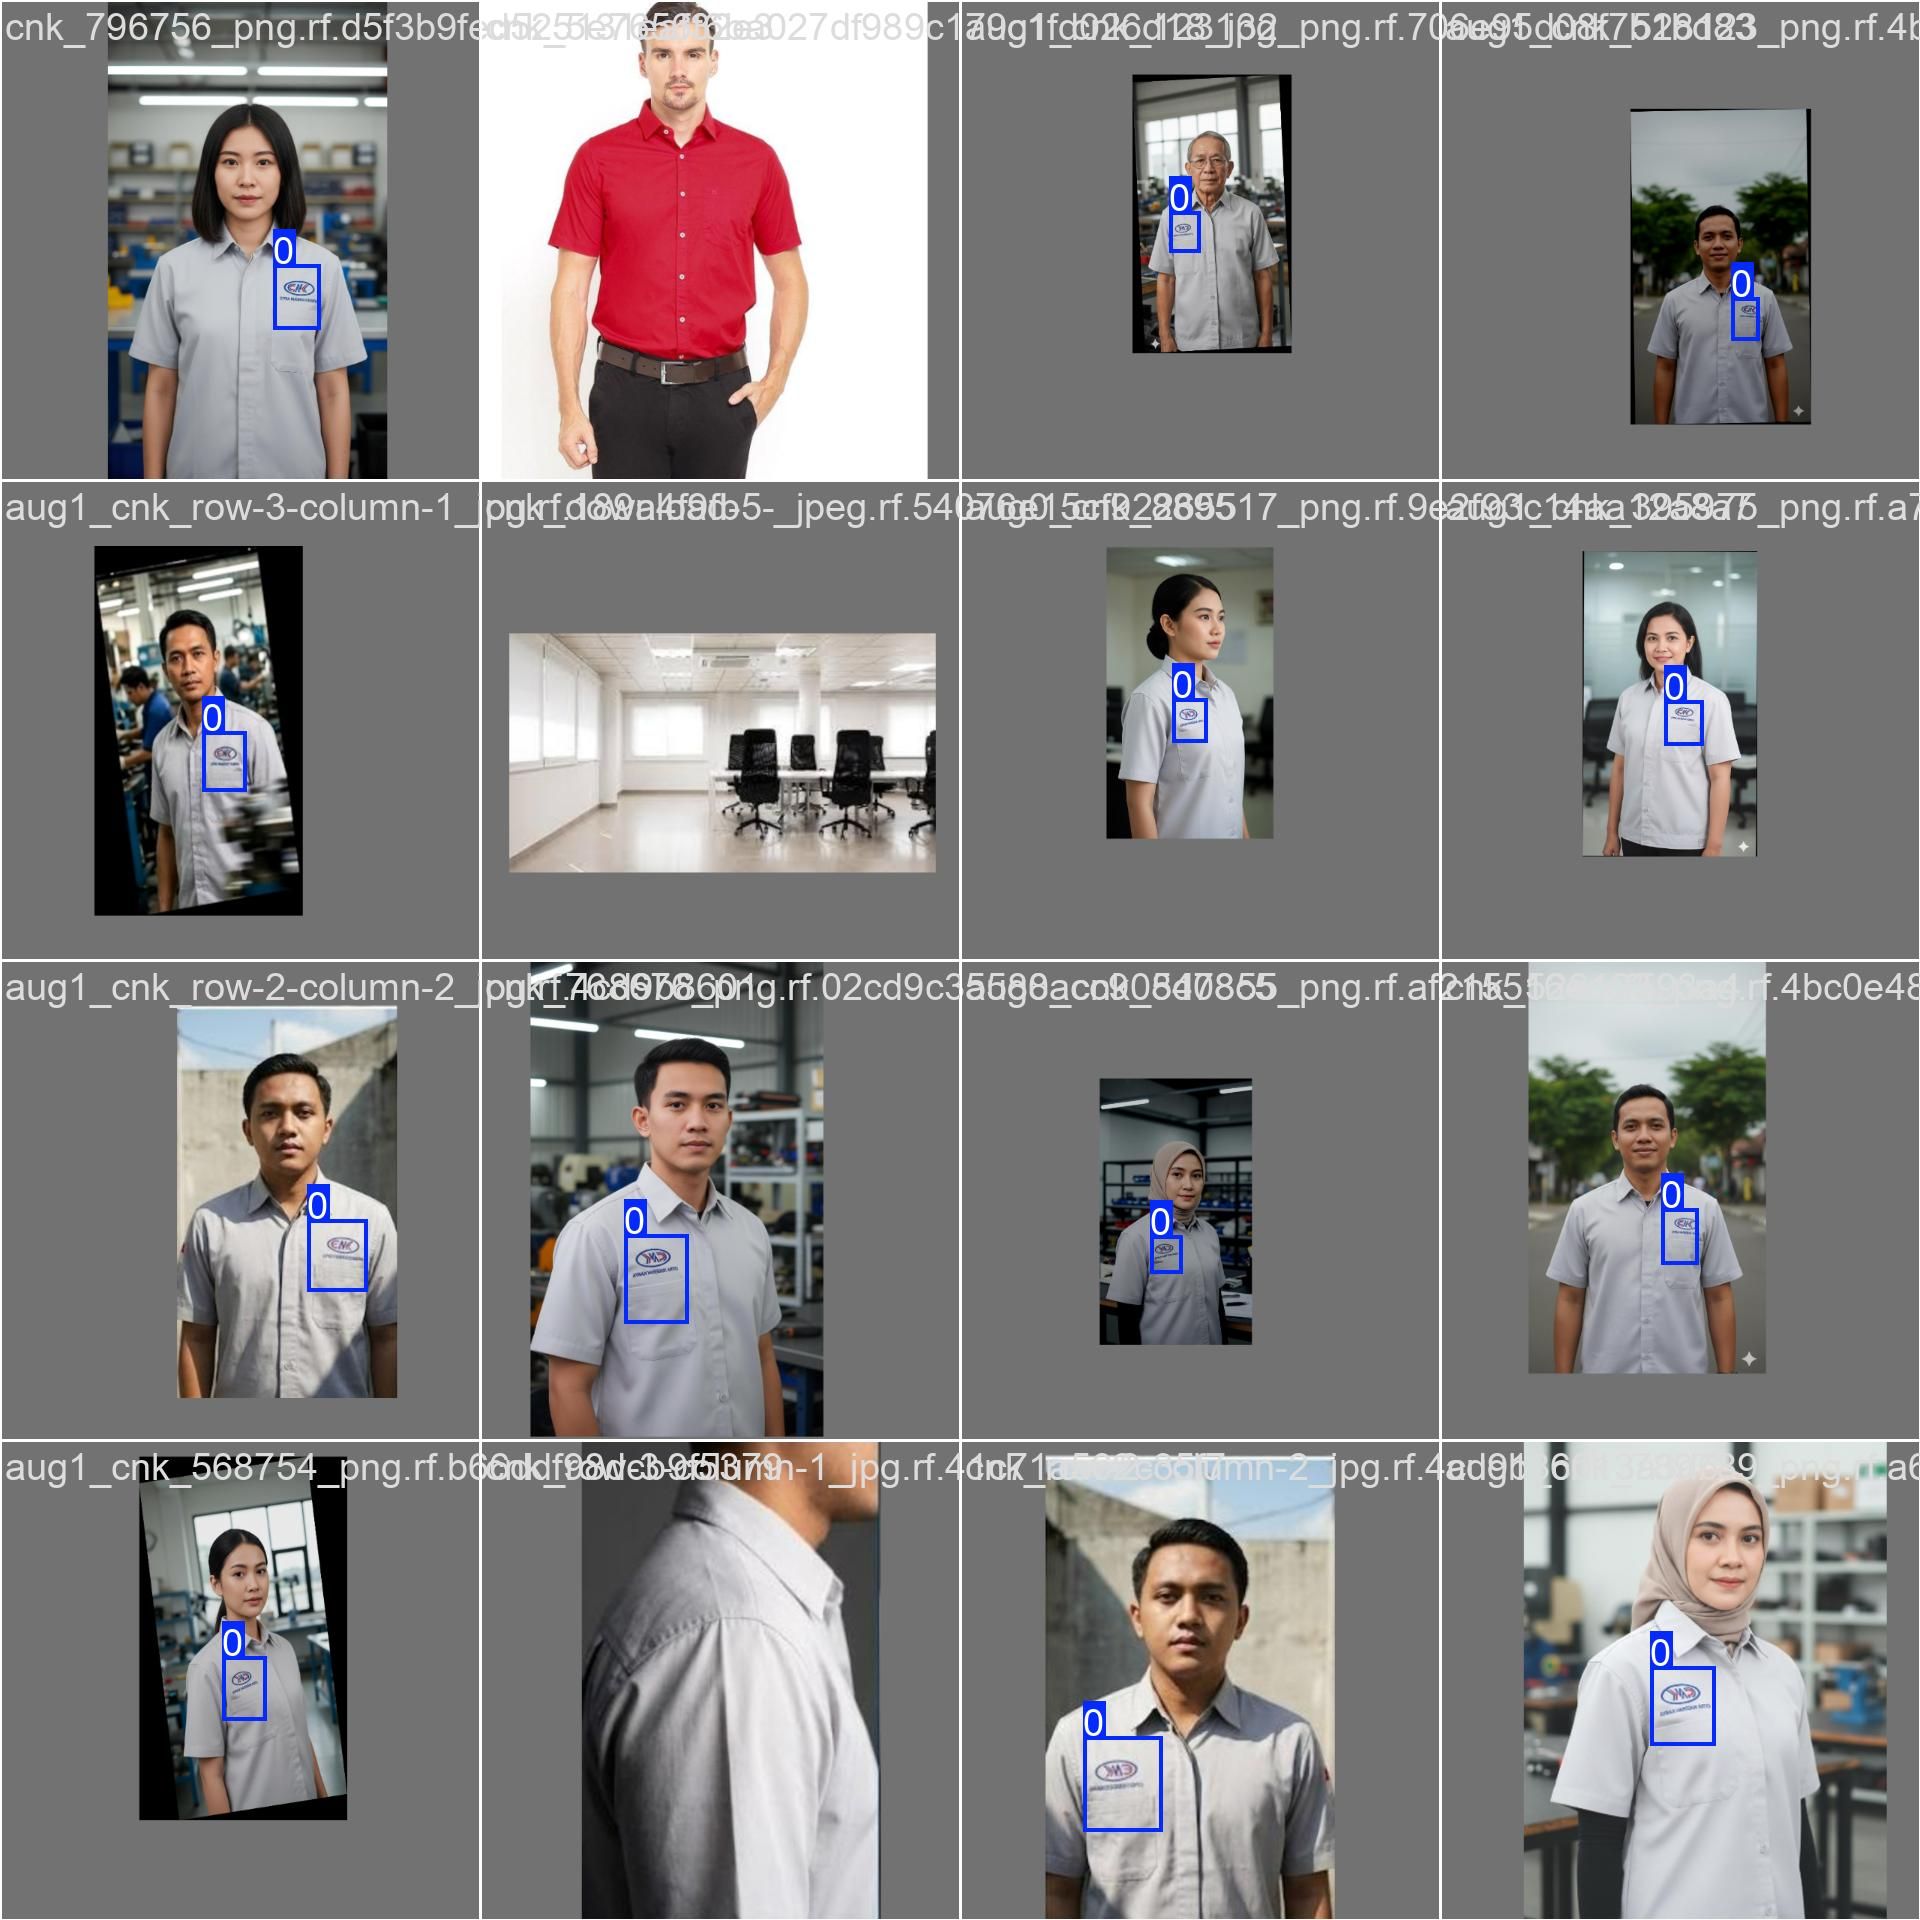

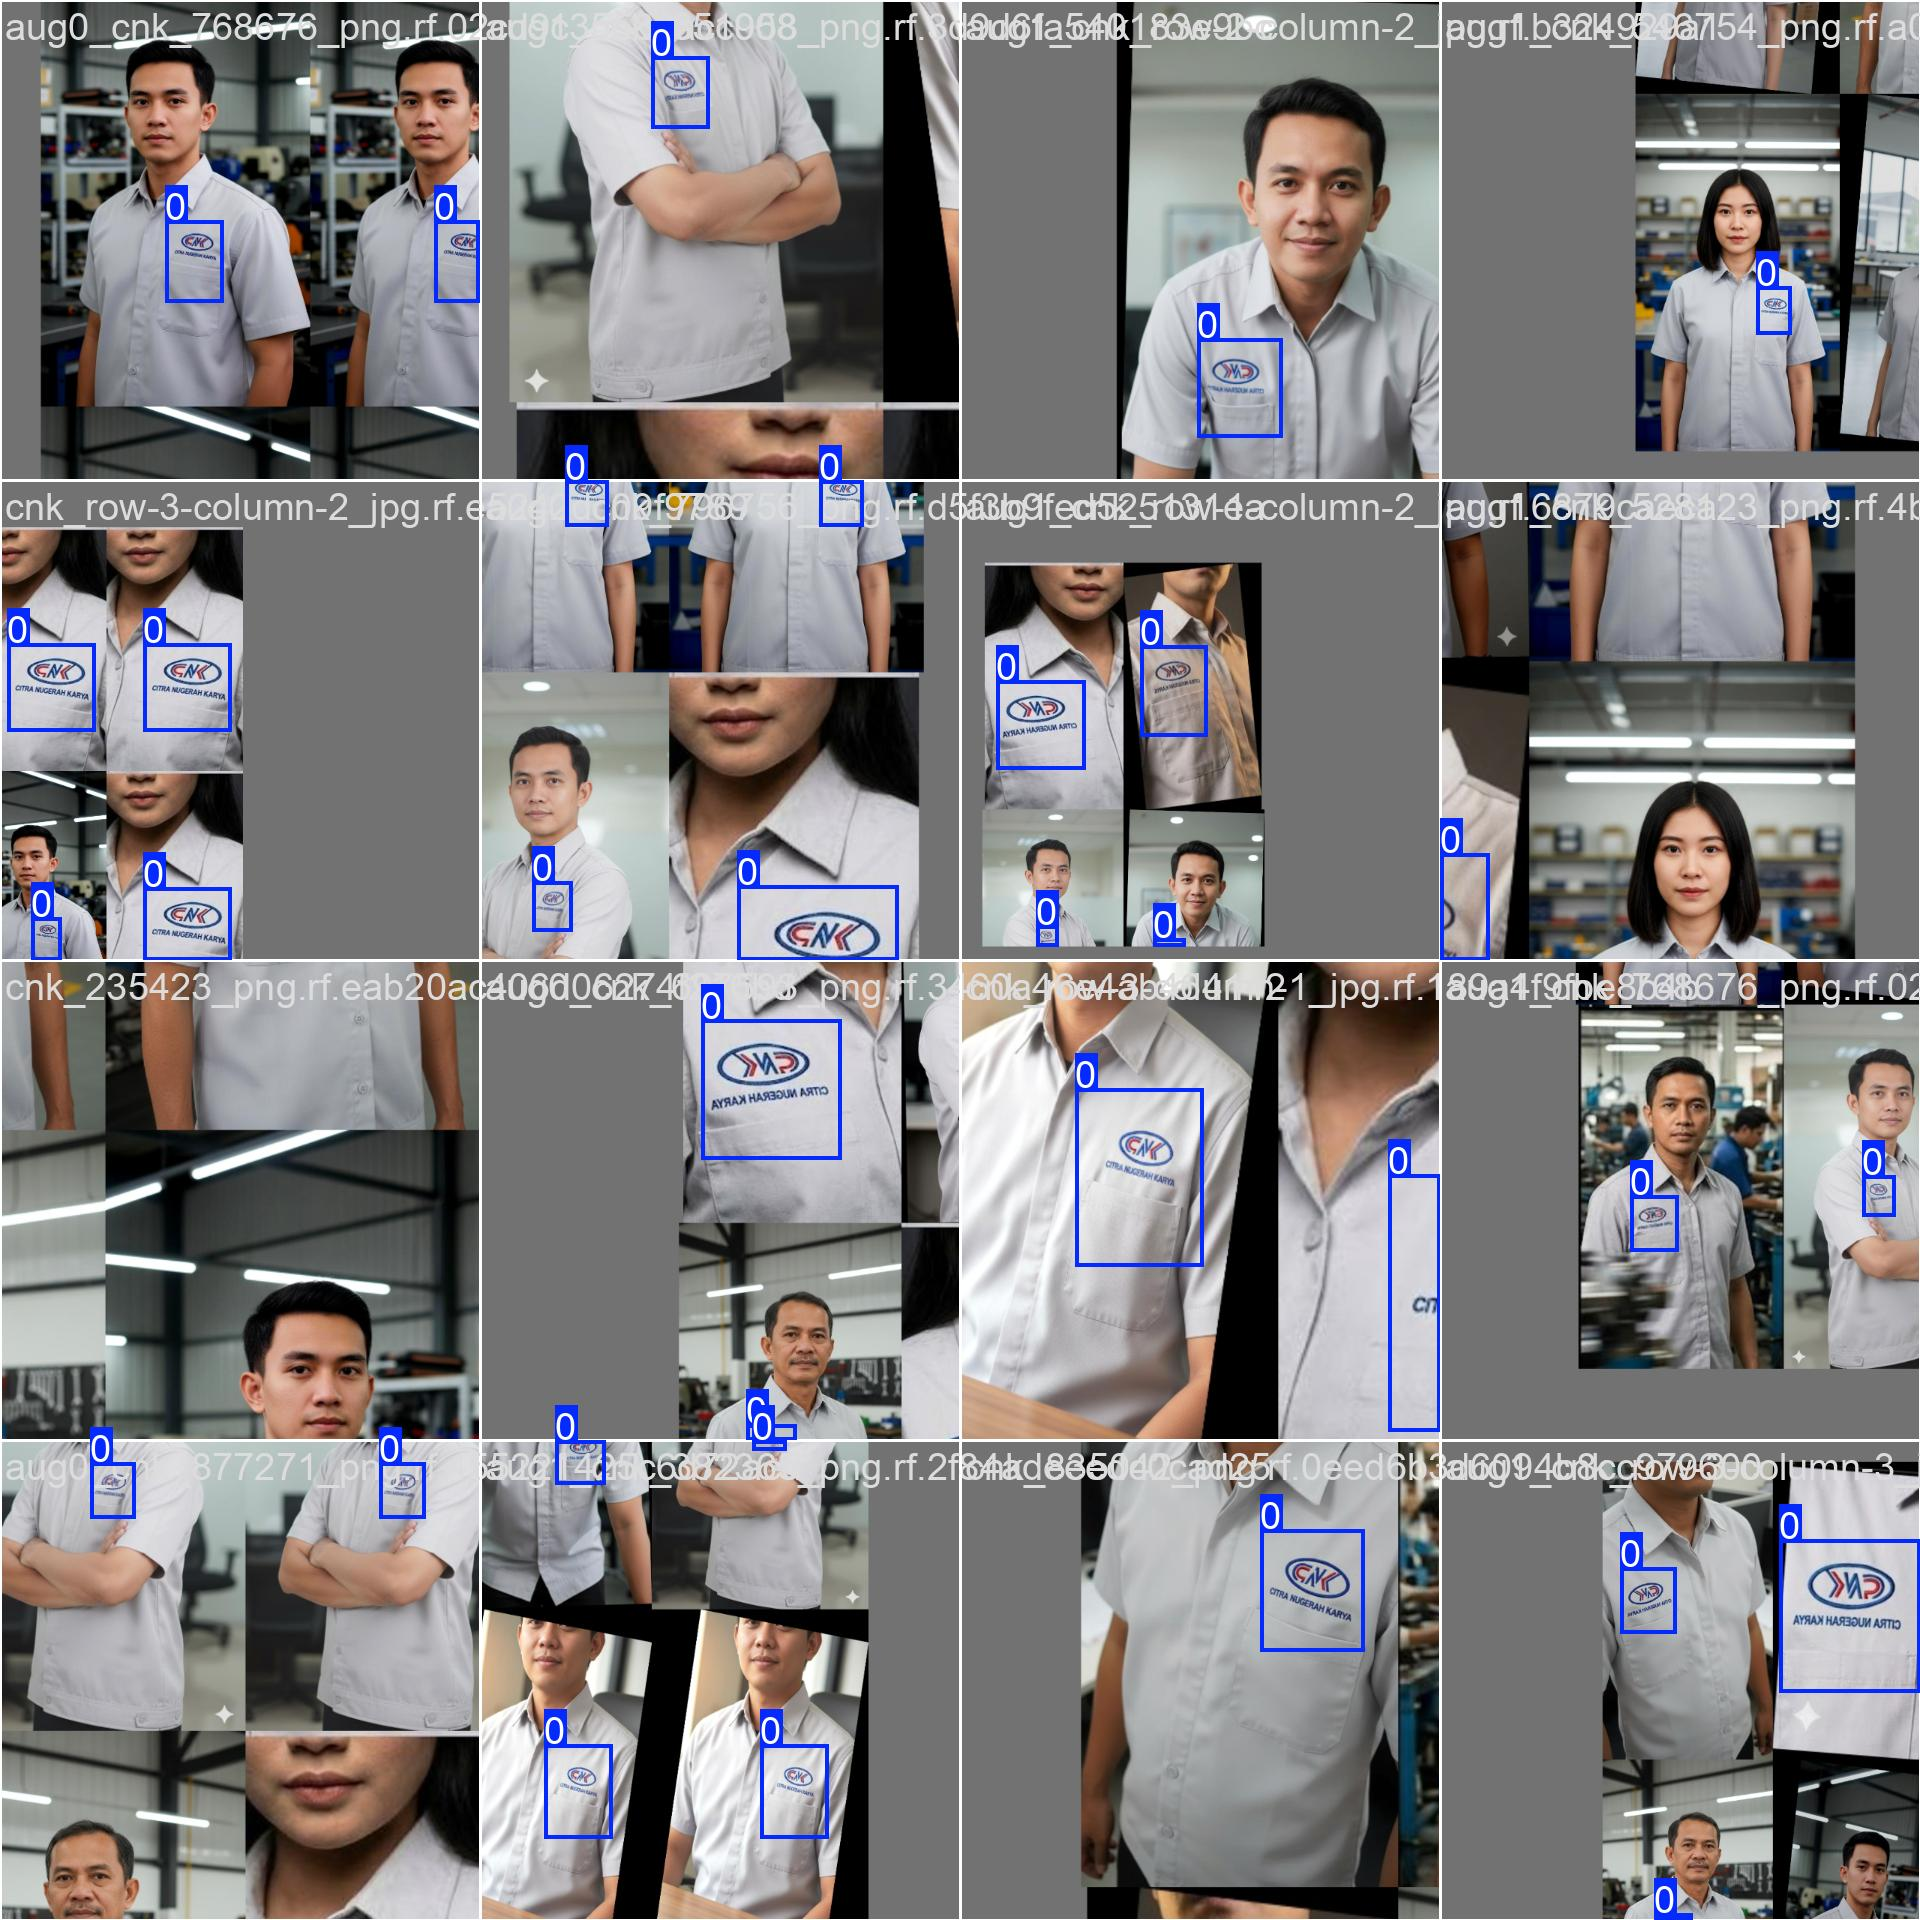

In [8]:
import glob
from IPython.display import Image, display

batch_images = glob.glob('/content/runs/detect/train/train_batch*.jpg')

if len(batch_images) > 0:
    print("📸 These are the augmentation results (Mosaic, etc.) being processed by YOLO:")
    for img_path in batch_images[:2]:
        display(Image(filename=img_path, width=800))
else:
    print("⏳ The image is not yet available. Ensure the training process has completed Epoch 1!")

In [22]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [24]:
import shutil
import os

model_source = '/content/runs/detect/train/weights/best.pt'

destination_folder = '/content/drive/MyDrive/Model_CNK_Project'
destination_file = os.path.join(destination_folder, 'yolov8_cnk_best.pt')

if os.path.exists(model_source):
    os.makedirs(destination_folder, exist_ok=True)

    shutil.copy(model_source, destination_file)
    print(f"✅ SUCCESS! The model was successfully secured to: {destination_file}")
else:
    print("❌ FAILED! File best.pt not found. Check the folder path again.")

✅ SUCCESS! The model was successfully secured to: /content/drive/MyDrive/Model_CNK_Project/yolov8_cnk_best.pt


In [25]:
metrics = model.val(split='test')
print(f"mAP50 accuracy on the original TEST data: {metrics.results_dict['metrics/mAP50(B)']}")

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1276.8±666.1 MB/s, size: 43.9 KB)
val: Scanning /content/Dataset_Super/test/labels.cache... 22 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         22         15      0.995          1      0.995      0.595
Speed: 8.6ms preprocess, 6.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50 accuracy on the original TEST data: 0.995
